# ¿Se puede ver venir el deterioro de una empresa un año antes?

**Autor:** Dumar Fabián Castañeda Ramos · [Portafolio](https://sites.google.com/view/dcfabianramos) · [LinkedIn](https://www.linkedin.com/in/dcfabianramos)

**Datos:** Superintendencia de Sociedades, *10.000 Empresas más Grandes del País*, cortes 2021 a 2025, publicado en [datos.gov.co](https://www.datos.gov.co/Comercio-Industria-y-Turismo/10-000-Empresas-mas-Grandes-del-Pa-s/6cat-2gcs). Cifras en **billones de pesos**, redondeadas a dos decimales.

**Qué se predice:** que una empresa sana en el año *t* reporte pérdida o patrimonio negativo en *t+1*. No es quiebra jurídica: es una señal contable de alarma. En Colombia el patrimonio negativo es causal de disolución.

**Resumen del resultado:** el modelo completo alcanza un AUC de 0,78, pero buena parte de ese acierto viene de un artefacto de redondeo ligado al tamaño de la empresa. Al corregirlo, el desempeño real queda cerca de 0,67. El recorrido hasta descubrirlo es el contenido de este cuaderno.

In [1]:
import collections, csv
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams.update({'figure.figsize': (9, 4.5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
TEAL, AMBAR, CIRUELA = '#0E7C6B', '#C98F0A', '#7A4E8C'

RUTA = 'empresas.csv'   # descárgalo de datos.gov.co

## 1. Carga

El archivo trae una fila por empresa y año de corte. La columna de cifras usa coma como separador de miles y símbolo de peso, así que hay que convertirla a número.

In [2]:
def a_numero(t):
    t = t.replace('$', '').replace(',', '').strip()
    neg = t.startswith('-')
    return (-1 if neg else 1) * float(t.lstrip('-')) if t else None

panel, info = collections.defaultdict(dict), {}
with open(RUTA, encoding='utf-8') as f:
    for fila in csv.DictReader(f):
        nit = fila['NIT'].replace(',', '')
        panel[nit][int(fila['Año de Corte'].replace(',', ''))] = dict(
            ing=a_numero(fila['INGRESOS OPERACIONALES']), gan=a_numero(fila['GANANCIA (PÉRDIDA)']),
            act=a_numero(fila['TOTAL ACTIVOS']), pas=a_numero(fila['TOTAL PASIVOS']),
            pat=a_numero(fila['TOTAL PATRIMONIO']))
        info[nit] = dict(nombre=fila['RAZÓN SOCIAL'].strip(), macro=fila['MACROSECTOR'].strip(),
                         region=fila['REGIÓN'].strip())

print(f'empresas distintas: {len(panel):,}')
print(f'presentes en los cinco cortes: {sum(1 for v in panel.values() if len(v) == 5):,}')

empresas distintas: 15,032
presentes en los cinco cortes: 5,917


## 2. Construcción de los pares

Cada registro combina los indicadores del año *t* con el desenlace del año *t+1*. Dos decisiones:

- **Solo entran empresas sanas en *t*** (con utilidad y patrimonio positivos). Predecir el deterioro de una que ya está mal no tiene valor práctico.
- **Los indicadores salen del año *t* únicamente.** Usar cualquier dato de *t+1* sería filtrar el futuro al modelo.

In [3]:
filas = []
for nit, años in panel.items():
    orden = sorted(años)
    for y in orden:
        if y + 1 not in años:
            continue
        a, b = años[y], años[y + 1]
        if a['gan'] < 0 or a['pat'] <= 0 or a['ing'] <= 0 or a['act'] <= 0:
            continue
        previo = años.get(y - 1)
        filas.append(dict(
            nit=nit, anio=y, nombre=info[nit]['nombre'],
            margen=a['gan'] / a['ing'], endeud=a['pas'] / a['act'],
            roa=a['gan'] / a['act'], roe=a['gan'] / a['pat'], rot_act=a['ing'] / a['act'],
            var_ing=(a['ing'] - previo['ing']) / previo['ing'] if previo and previo['ing'] > 0 else 0.0,
            tam=a['ing'], anios_lista=sum(1 for z in orden if z <= y),
            macro=info[nit]['macro'], region=info[nit]['region'],
            objetivo=1 if (b['gan'] < 0 or b['pat'] < 0) else 0))

df = pd.DataFrame(filas)
df['log_tam'] = np.log10(df.tam.clip(lower=0.01))
print(f'pares: {len(df):,} | casos de deterioro: {df.objetivo.sum():,} ({df.objetivo.mean()*100:.1f} %)')
df.groupby('anio').objetivo.agg(['size', 'sum', 'mean']).rename(
    columns={'size': 'pares', 'sum': 'deterioros', 'mean': 'tasa'})

pares: 26,123 | casos de deterioro: 788 (3.0 %)


,pares,deterioros,tasa
anio,,,
2021,6463,171,0.026458
2022,6280,219,0.034873
2023,6663,226,0.033919
2024,6717,172,0.025607


## 3. Exploración: ¿qué perfil se deteriora más?

Antes de modelar, conviene mirar la tasa de deterioro por tramos de cada indicador. Si ninguna variable separa, ningún algoritmo lo arreglará.

In [4]:
def tasa_por_cuartil(col):
    q = pd.qcut(df[col], 4, duplicates='drop')
    t = df.groupby(q, observed=True).objetivo.agg(['size', 'mean'])
    t['mean'] = (t['mean'] * 100).round(2)
    return t.rename(columns={'size': 'empresas', 'mean': 'tasa_%'})

for col in ['endeud', 'rot_act', 'margen', 'tam']:
    print(f'--- {col} ---')
    print(tasa_por_cuartil(col).to_string(), '\n')

--- endeud ---
                 empresas  tasa_%
endeud                           
(-0.001, 0.333]      7427    1.87
(0.333, 0.5]         7627    1.74
(0.5, 0.667]         5291    3.50
(0.667, 1.0]         5778    5.73 

--- rot_act ---
                                empresas  tasa_%
rot_act                                         
(0.0017200000000000002, 0.826]      6532    5.07
(0.826, 1.3]                        6542    2.89
(1.3, 2.0]                          8034    1.99
(2.0, 48.0]                         5015    2.15 

--- margen ---
                  empresas  tasa_%
margen                            
(-0.001, 0.0625]     19594    3.08
(0.0625, 25.0]        6529    2.82 

--- tam ---
                              empresas  tasa_%
tam                                           
(0.009000000000000001, 0.03]      7792    0.65
(0.03, 0.06]                      6812    1.83
(0.06, 0.12]                      5046    3.15
(0.12, 144.82]                    6473    7.00 



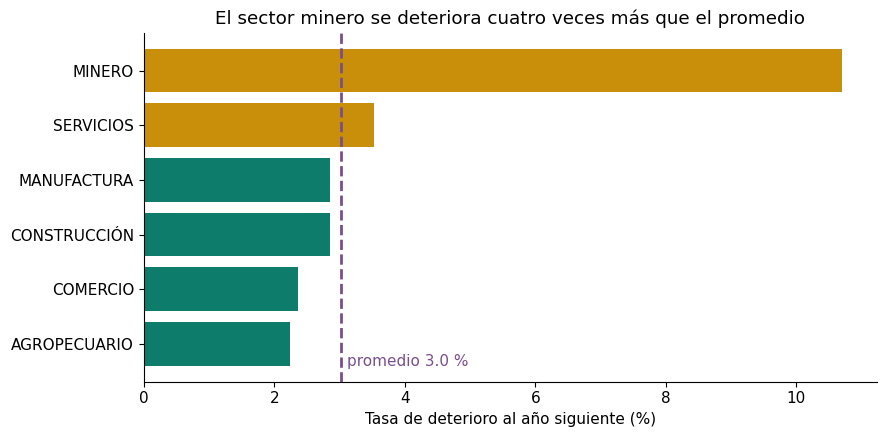

In [5]:
sect = df.groupby('macro').objetivo.agg(['size', 'mean']).sort_values('mean')
fig, ax = plt.subplots()
ax.barh(sect.index, sect['mean'] * 100, color=[AMBAR if v > df.objetivo.mean() else TEAL for v in sect['mean']])
ax.axvline(df.objetivo.mean() * 100, color=CIRUELA, ls='--', lw=2)
ax.text(df.objetivo.mean() * 100 + 0.1, -0.4, f'promedio {df.objetivo.mean()*100:.1f} %', color=CIRUELA)
ax.set_xlabel('Tasa de deterioro al año siguiente (%)')
ax.set_title('El sector minero se deteriora cuatro veces más que el promedio')
plt.tight_layout(); plt.show()

## 4. Separación temporal

Entreno con los pares de 2021 y 2022, y evalúo con los de 2023 y 2024.

Una partición aleatoria pondría a la misma empresa en ambos lados y dejaría que el modelo viera el futuro: el AUC subiría sin que el modelo fuera mejor. En riesgo de crédito la validación siempre es temporal.

In [6]:
NUM = ['margen', 'endeud', 'roa', 'roe', 'rot_act', 'var_ing', 'anios_lista', 'log_tam']
CAT = ['macro', 'region']
entreno, prueba = df[df.anio <= 2022], df[df.anio >= 2023]
print(f'entreno {len(entreno):,} ({entreno.objetivo.sum()} casos) | prueba {len(prueba):,} ({prueba.objetivo.sum()} casos)')

def ajustar(datos, numericas=NUM, algoritmo=None):
    if algoritmo is None:
        algoritmo = LogisticRegression(max_iter=2000, class_weight='balanced')
    pre = ColumnTransformer([('num', StandardScaler(), numericas),
                             ('cat', OneHotEncoder(handle_unknown='ignore'), CAT)])
    tr, te = datos[datos.anio <= 2022], datos[datos.anio >= 2023]
    modelo = make_pipeline(pre, algoritmo).fit(tr[numericas + CAT], tr.objetivo)
    puntaje = modelo.predict_proba(te[numericas + CAT])[:, 1]
    return modelo, puntaje, roc_auc_score(te.objetivo, puntaje)

modelo, puntaje, auc = ajustar(df)
_, _, auc_bosque = ajustar(df, algoritmo=RandomForestClassifier(
    n_estimators=400, min_samples_leaf=20, class_weight='balanced', random_state=0, n_jobs=-1))
print(f'\nAUC regresión logística: {auc:.3f}')
print(f'AUC bosque aleatorio:    {auc_bosque:.3f}')

entreno 12,743 (390 casos) | prueba 13,380 (398 casos)



AUC regresión logística: 0.777
AUC bosque aleatorio:    0.795


### Por qué no uso la exactitud

Con un 3 % de casos positivos, un modelo que diga *«nadie se deteriora»* acierta el 97 % de las veces y no sirve para nada. Las métricas honestas aquí son el AUC y, sobre todo, cuántos casos captura el grupo de mayor riesgo.

In [7]:
prueba = prueba.copy()
prueba['prob'] = puntaje
prueba['decil'] = pd.qcut(prueba.prob, 10, labels=range(10, 0, -1)).astype(int)
dec = prueba.groupby('decil').agg(empresas=('objetivo', 'size'), casos=('objetivo', 'sum'),
                                  tasa=('objetivo', 'mean')).sort_index()
dec['tasa'] = (dec.tasa * 100).round(2)
dec['lift'] = (dec.tasa / (prueba.objetivo.mean() * 100)).round(2)
dec['captura_acum_%'] = (dec.casos.cumsum() / dec.casos.sum() * 100).round(1)
dec

,empresas,casos,tasa,lift,captura_acum_%
decil,,,,,
1,1338,140,10.46,3.52,35.2
2,1338,97,7.25,2.44,59.5
3,1338,55,4.11,1.38,73.4
4,1338,34,2.54,0.85,81.9
5,1338,19,1.42,0.48,86.7
6,1338,13,0.97,0.33,89.9
7,1338,12,0.90,0.30,93.0
8,1338,12,0.90,0.30,96.0
9,1338,9,0.67,0.23,98.2


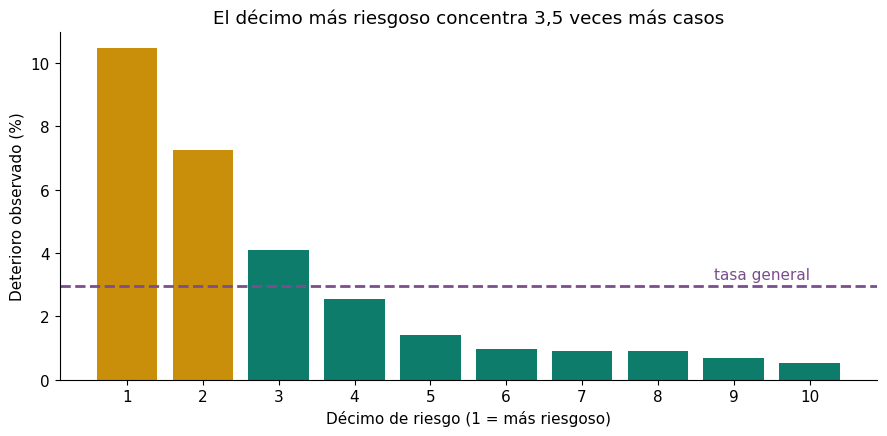

In [8]:
fig, ax = plt.subplots()
ax.bar(dec.index, dec.tasa, color=[AMBAR if i <= 2 else TEAL for i in dec.index])
ax.axhline(prueba.objetivo.mean() * 100, color=CIRUELA, ls='--', lw=2)
ax.text(10, prueba.objetivo.mean() * 100 + 0.2, 'tasa general', color=CIRUELA, ha='right')
ax.set_xticks(range(1, 11)); ax.set_xlabel('Décimo de riesgo (1 = más riesgoso)')
ax.set_ylabel('Deterioro observado (%)')
ax.set_title('El décimo más riesgoso concentra 3,5 veces más casos')
plt.tight_layout(); plt.show()

## 5. La trampa: el tamaño

El coeficiente más fuerte del modelo es el tamaño de la empresa, y apunta en una dirección sospechosa: las grandes aparecen como más propensas al deterioro. Eso contradice la literatura y el sentido común.

La explicación no es económica sino de medición. Las cifras vienen **redondeadas a dos decimales en billones de pesos**: una empresa que gana 3.000 millones aparece como `0,00`. Si su ganancia nunca puede mostrarse negativa, nunca se cuenta como deterioro.

In [9]:
df['gan_abs'] = (df.margen * df.tam).abs()
cuartil = pd.qcut(df.tam, 4)
redondeo = df.assign(cero=df.gan_abs < 0.005).groupby(cuartil, observed=True).agg(
    empresas=('cero', 'size'), pct_en_cero=('cero', lambda s: round(s.mean() * 100, 1)),
    tasa_deterioro=('objetivo', lambda s: round(s.mean() * 100, 2)))
redondeo

,empresas,pct_en_cero,tasa_deterioro
tam,,,
"(0.009000000000000001, 0.03]",7792,90.1,0.65
"(0.03, 0.06]",6812,80.1,1.83
"(0.06, 0.12]",5046,59.6,3.15
"(0.12, 144.82]",6473,29.3,7.00


Nueve de cada diez empresas del cuartil más pequeño tienen una ganancia que redondea a cero. La supuesta «solidez» de las pequeñas es, en buena parte, incapacidad del dato para registrar su deterioro.

### La prueba: quitar la variable y volver a medir

In [10]:
sin_tam = [c for c in NUM if c != 'log_tam']
_, _, auc_sin = ajustar(df, numericas=sin_tam)
grandes = df[df.tam >= 0.12]          # solo el cuartil superior, donde el redondeo pesa menos
_, _, auc_grandes = ajustar(grandes)
_, _, auc_grandes_sin = ajustar(grandes, numericas=sin_tam)

comparacion = pd.DataFrame({
    'modelo': ['Todas las variables', 'Sin la variable de tamaño',
               'Solo empresas grandes', 'Solo grandes y sin tamaño',
               'Regla simple: endeudamiento', 'Regla simple: margen bajo'],
    'auc': [round(auc, 3), round(auc_sin, 3), round(auc_grandes, 3), round(auc_grandes_sin, 3),
            round(roc_auc_score(prueba.objetivo, prueba.endeud), 3),
            round(roc_auc_score(prueba.objetivo, -prueba.margen), 3)]})
comparacion

,modelo,auc
0,Todas las variables,0.777
1,Sin la variable de tamaño,0.660
2,Solo empresas grandes,0.667
3,Solo grandes y sin tamaño,0.641
4,Regla simple: endeudamiento,0.628
5,Regla simple: margen bajo,0.456


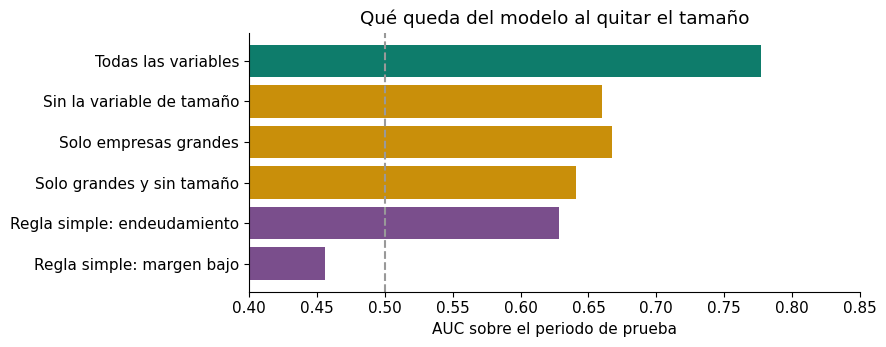

In [11]:
fig, ax = plt.subplots(figsize=(9, 3.6))
colores = [TEAL, AMBAR, AMBAR, AMBAR, CIRUELA, CIRUELA]
ax.barh(comparacion.modelo[::-1], comparacion.auc[::-1], color=colores[::-1])
ax.axvline(0.5, color='#999', ls='--'); ax.set_xlim(0.4, 0.85)
ax.set_xlabel('AUC sobre el periodo de prueba'); ax.set_title('Qué queda del modelo al quitar el tamaño')
plt.tight_layout(); plt.show()

## 6. Conclusiones

1. **El modelo sirve para priorizar, no para decidir.** El décimo más riesgoso concentra unas 3,5 veces más casos que el promedio: revisar ahí primero rinde. Negar un cupo de crédito con este puntaje, no.

2. **El AUC de 0,78 está inflado.** Al quitar el tamaño cae a 0,66, y entre empresas comparables queda en 0,67. Publicar el primero sin la advertencia sería vender un resultado que no se sostiene.

3. **Aun así, supera al criterio de pulgar.** Mirar solo el endeudamiento da 0,63, y mirar solo el margen no sirve (0,46, peor que el azar).

4. **Falta lo esencial:** sin activos y pasivos corrientes no hay razón corriente ni prueba ácida, que son las variables que de verdad anticipan una insolvencia. Las empresas no caen por dejar de ser rentables, sino por quedarse sin con qué pagar.

5. **Sesgo de supervivencia:** el listado solo incluye a las 10.000 empresas más grandes, las que menos quiebran. Este modelo no se puede aplicar a una pyme.

### Qué haría a continuación

Cruzar con los estados financieros completos del SIREM, que sí traen el desagregado corriente, y con los procesos de insolvencia publicados por la Superintendencia, para reemplazar la señal indirecta por el desenlace real.